# Data Visualization for Curb/Asphalt road

In [2]:
# Enable autoload for just updated files
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import sys
import pandas as pd  
import matplotlib.pyplot as plt
import pickle
import numpy as np
sys.path.append('../../')   # Add parent directory to Python path
from utils.visualization import *
from notebooks.training.transformations import *  

Curb Dataset: Lab Dataset with ideal Labels<br>
a. curb 1cm<br>
b. curb 2cm<br>
c. curb 3cm<br>
d. ramp 0cm to 3cm<br>
e. transition stone 0cm to 3cm<br>
P3,P6,P11,P12,P18,P21

## Curb/Normal cycling segmentation

In [8]:
with open('../../notebooks/data_1s_100hz_7classes/TrainTest/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../../notebooks/data_1s_100hz_7classes/TrainTest/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)

0: asphalt
1: cobblestone
2: compact_gravel
3: curb_0
4: curb_1
5: dirt
6: paving_stone

In [24]:
# Get indices for curb and asphalt samples
curb_indices = np.where(np_train_labels[:, 4] == 1)[0]  # Class 4 (curb_1)
asphalt_indices = np.where(np_train_labels[:, 0] == 1)[0]  # Class 0 (asphalt)

# Extract curb and asphalt samples
curb_samples = np_train_data[curb_indices]
asphalt_samples = np_train_data[asphalt_indices]

# Print shapes to verify
print(f"Curb samples shape: {curb_samples.shape}")
print(f"Asphalt samples shape: {asphalt_samples.shape}")

Curb samples shape: (375, 100, 3)
Asphalt samples shape: (449, 100, 3)


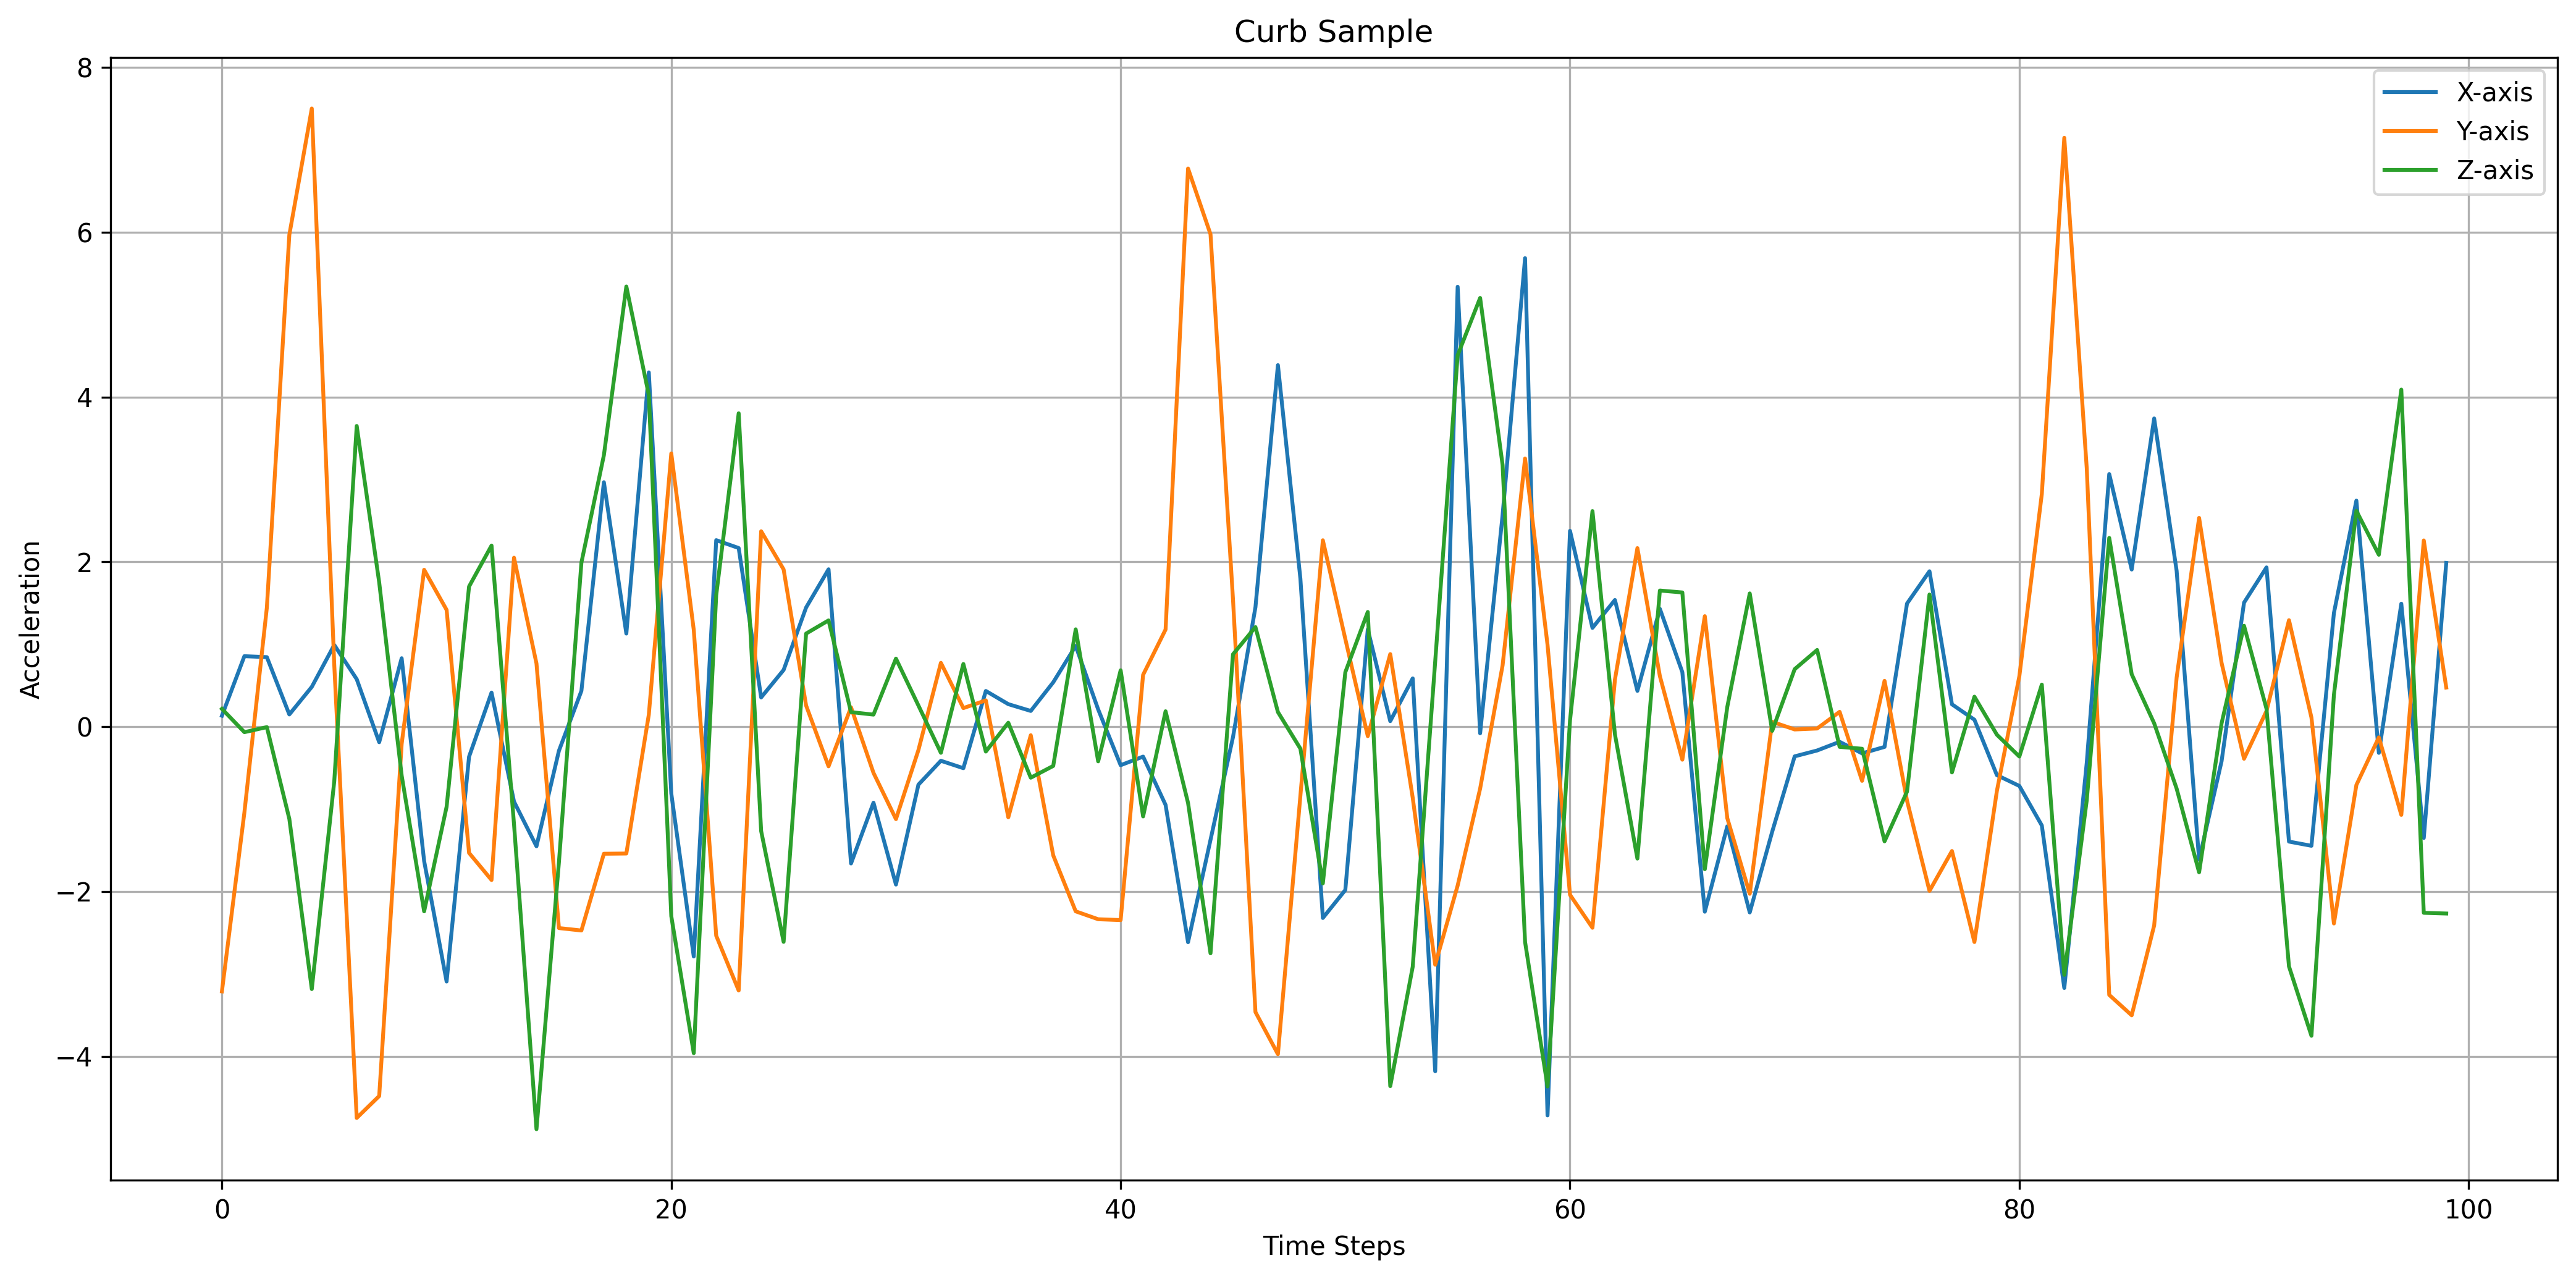

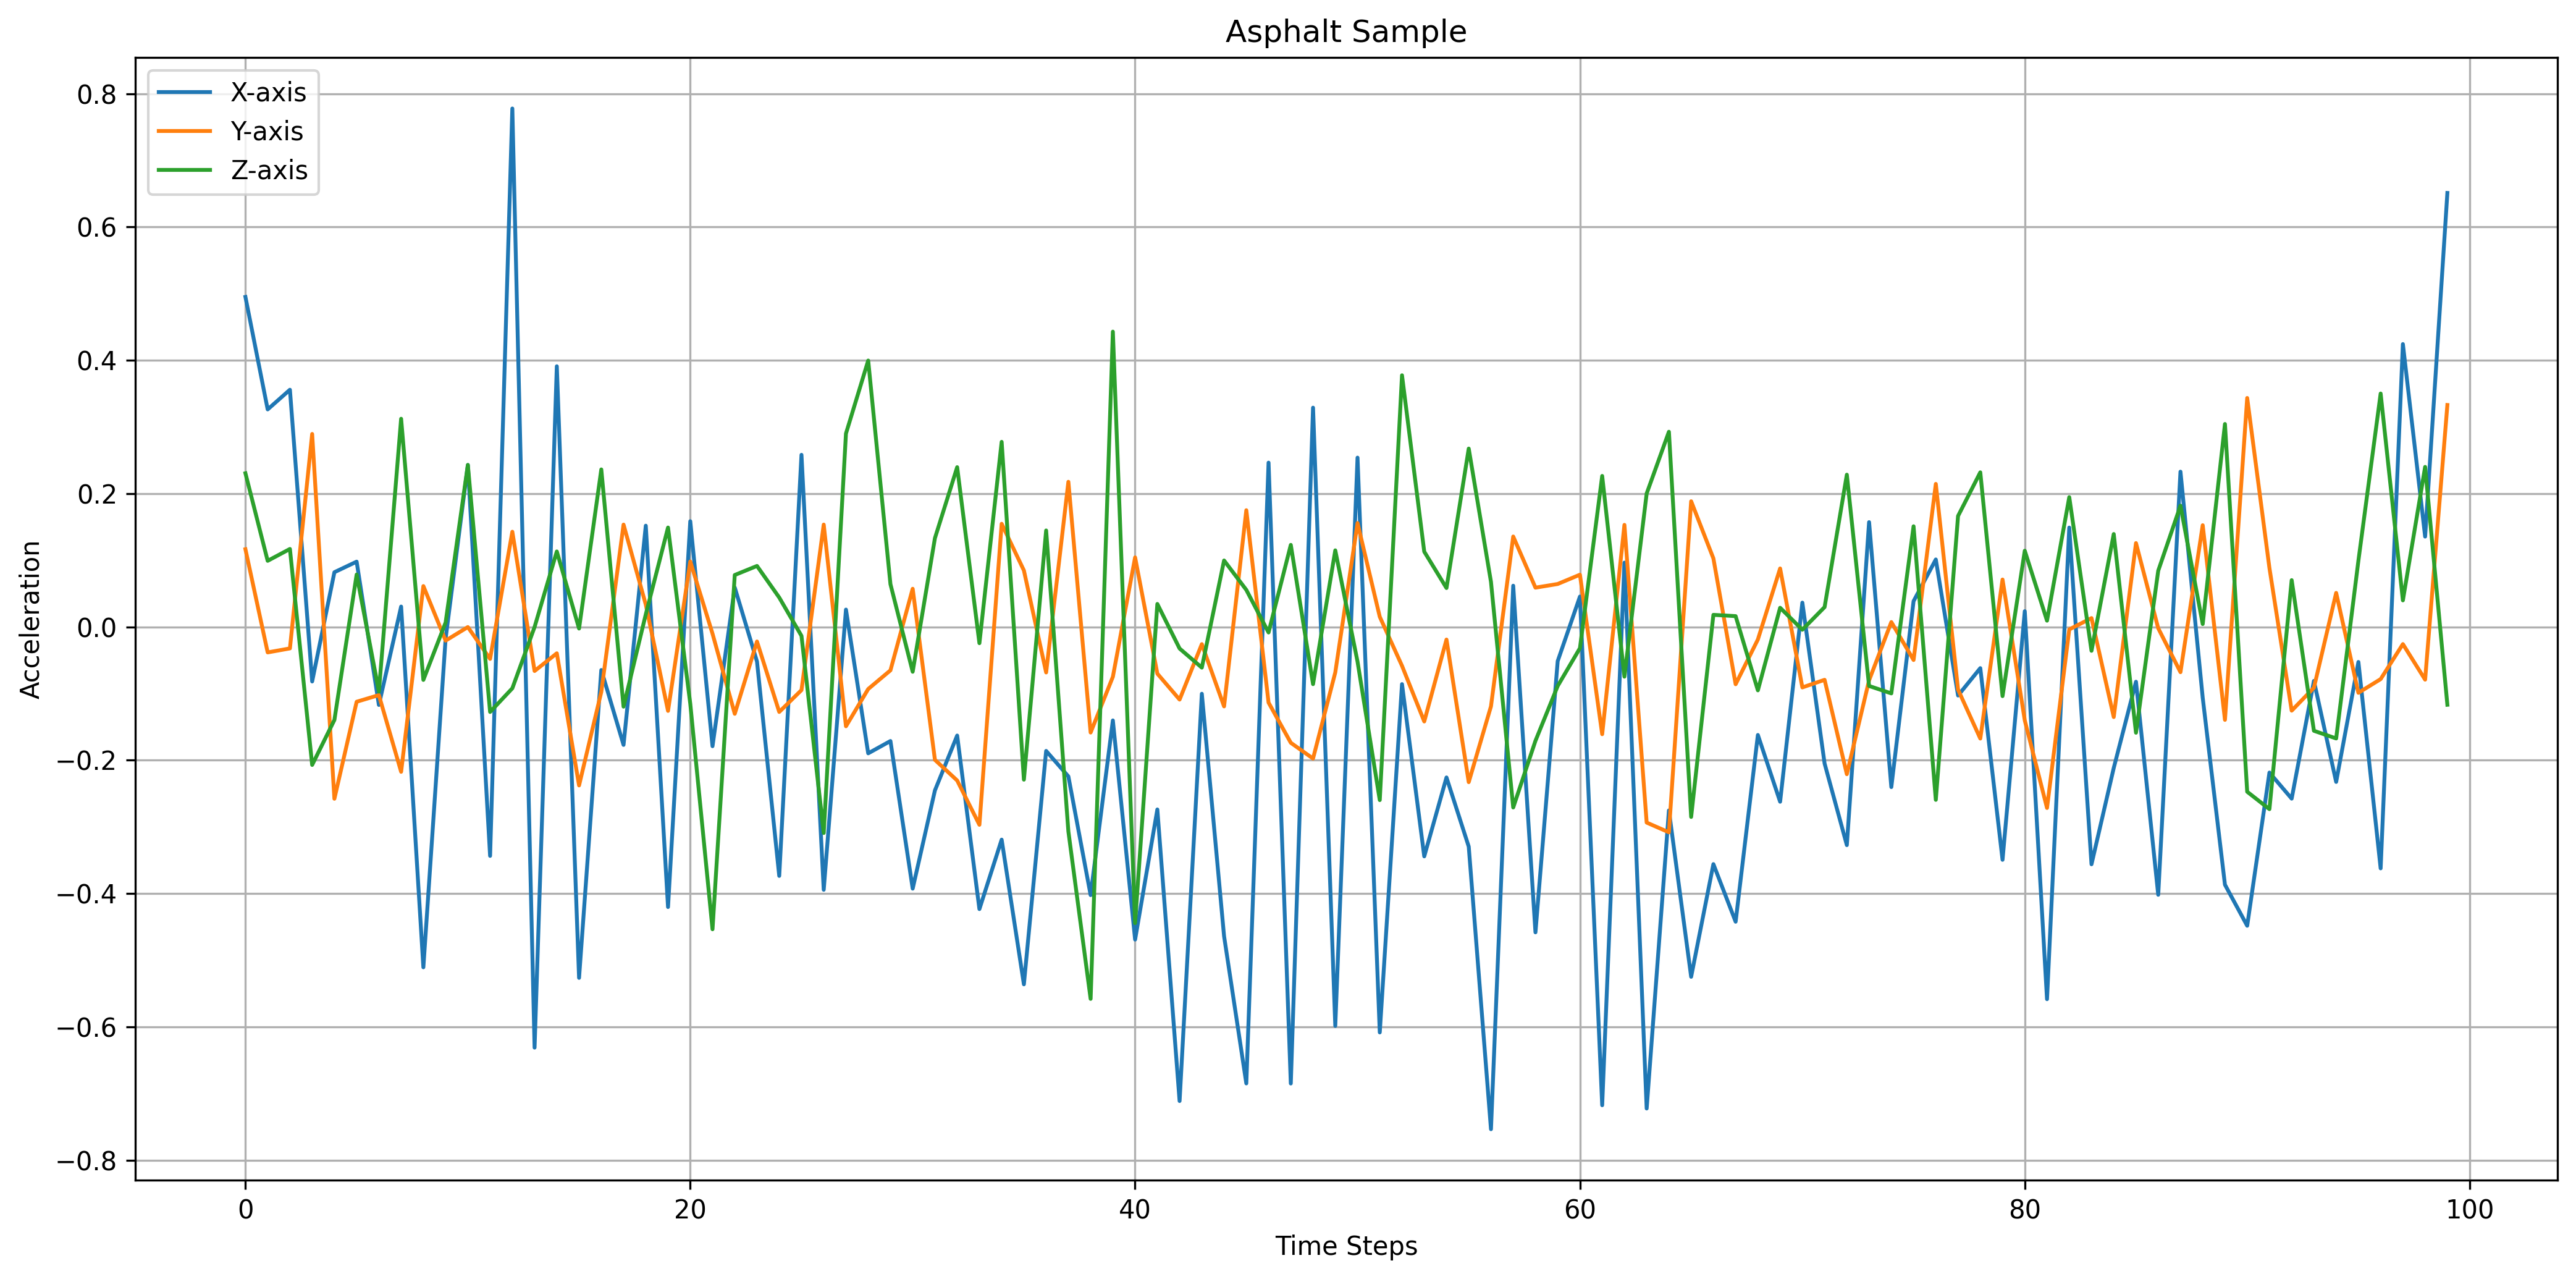

In [26]:
# Plot a curb sample
plot_sample_data_numpy_bachelorarbeit(curb_samples[30], title="Curb Sample")

# Plot an asphalt sample
plot_sample_data_numpy_bachelorarbeit(asphalt_samples[30], title="Asphalt Sample")

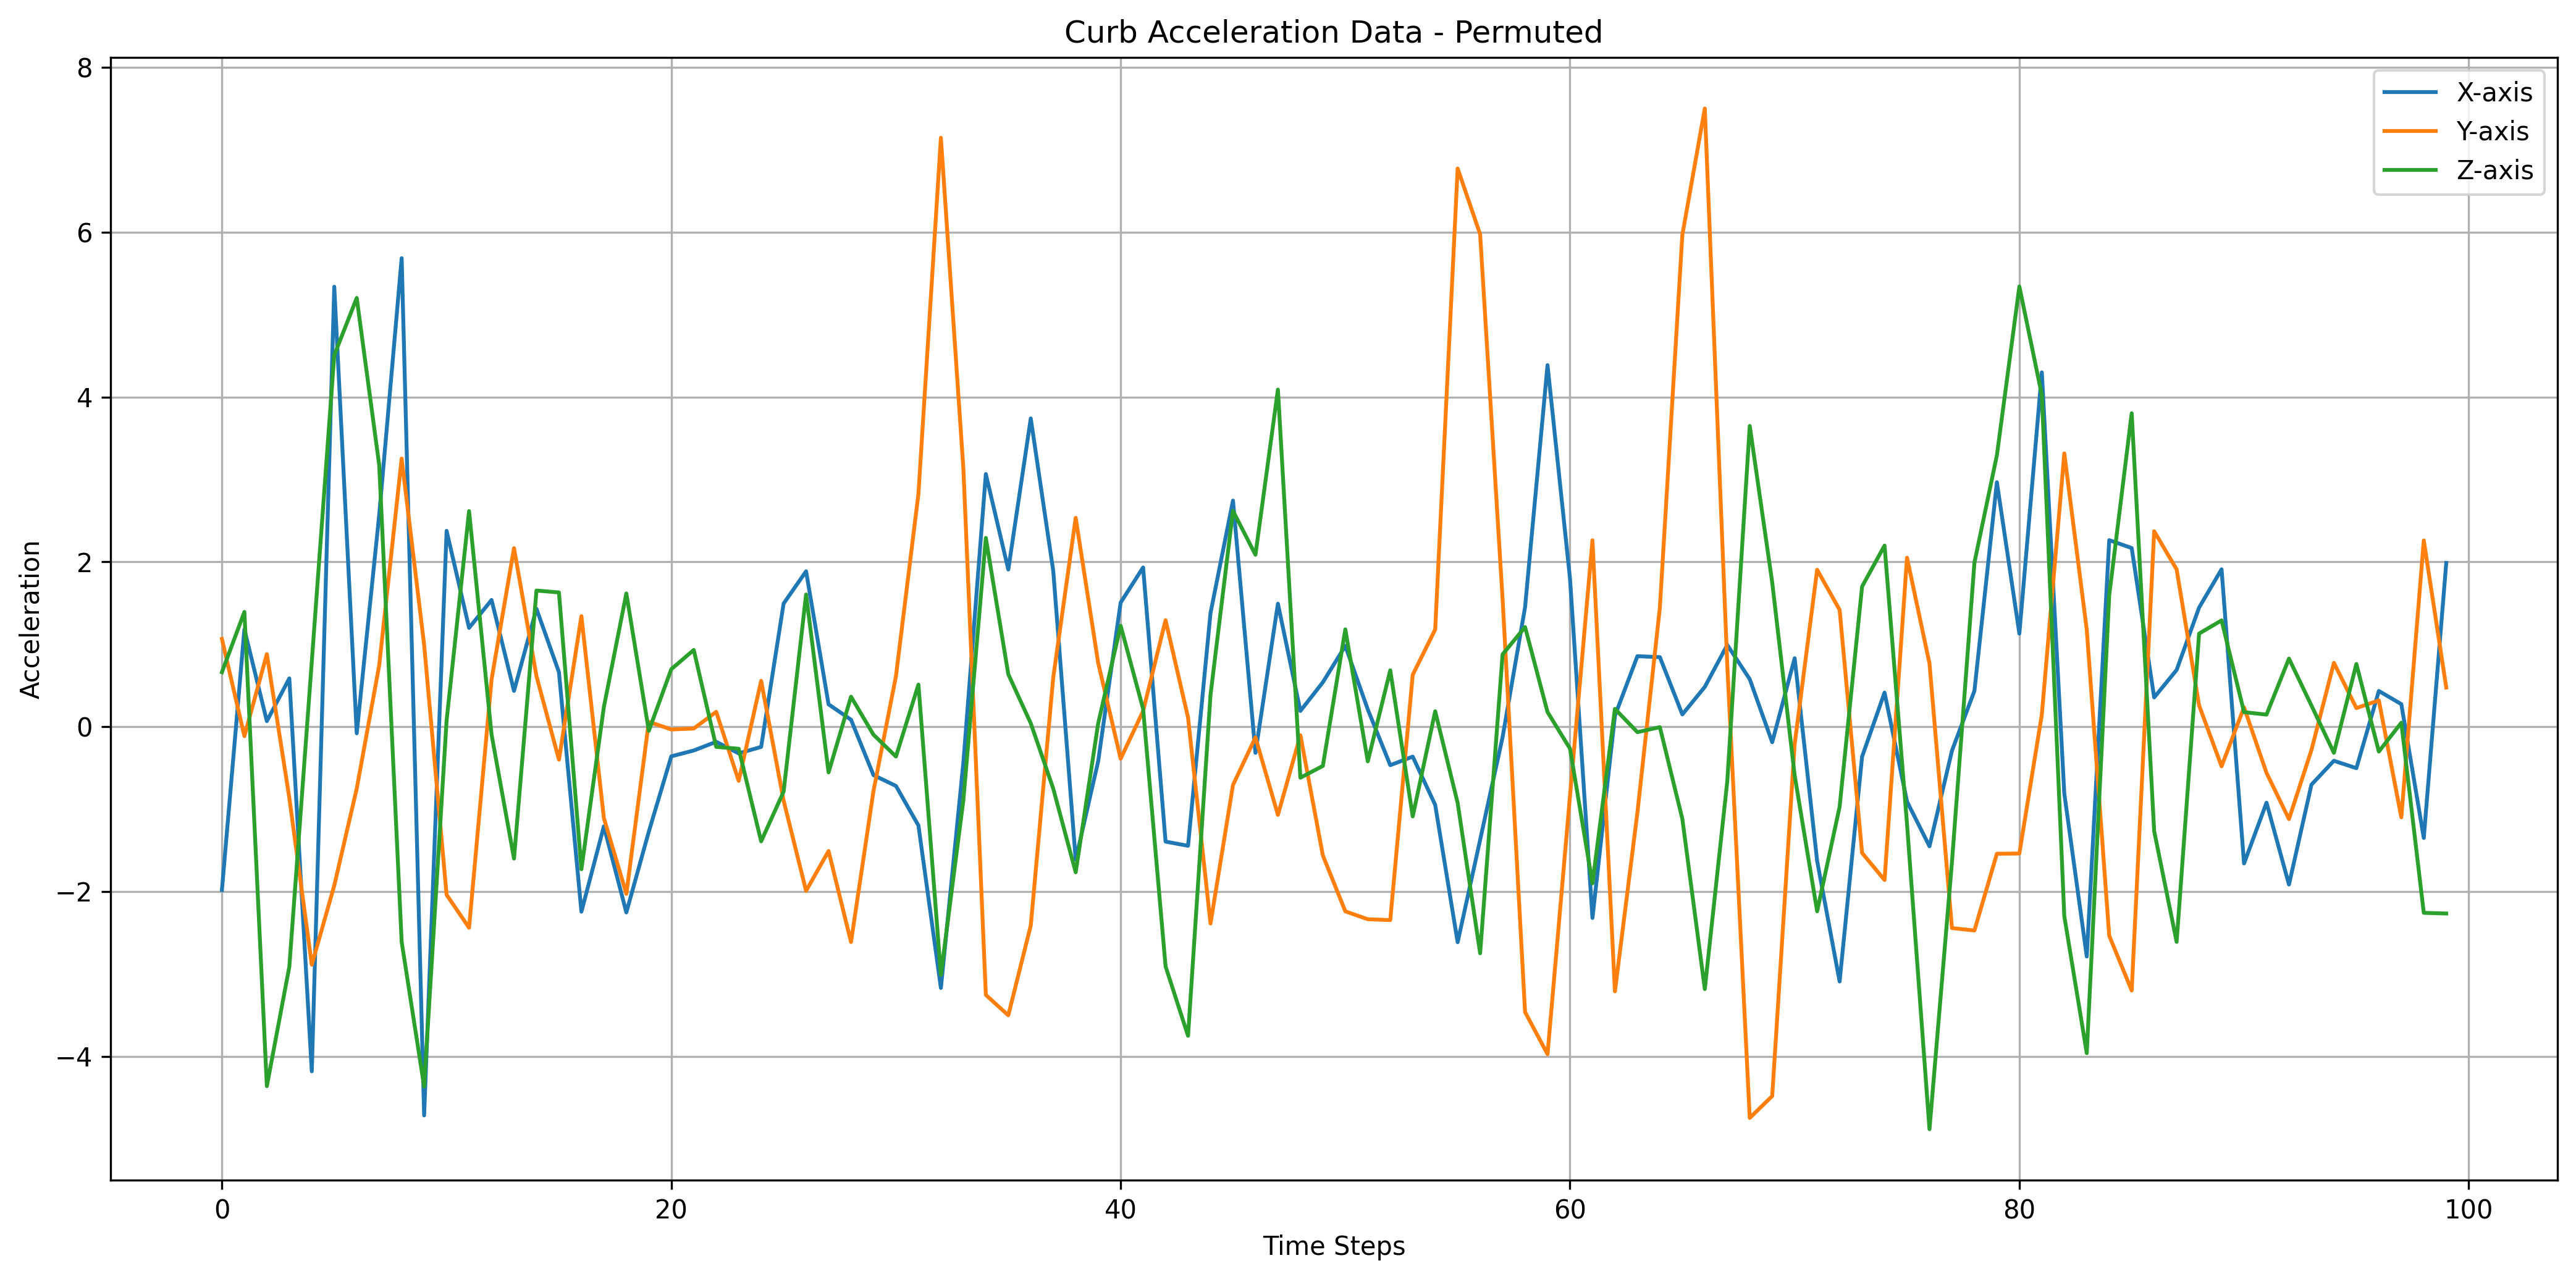

In [32]:
# Apply and plot time segment permutation
sample = np.expand_dims(curb_samples[30], axis=0)  # Add batch dimension
permuted_curb = time_segment_permutation_transform_improved(sample)
permuted_curb = np.squeeze(permuted_curb)  # Remove batch dimension
plot_sample_data_numpy_bachelorarbeit(permuted_curb, title="Curb Acceleration Data - Permuted")

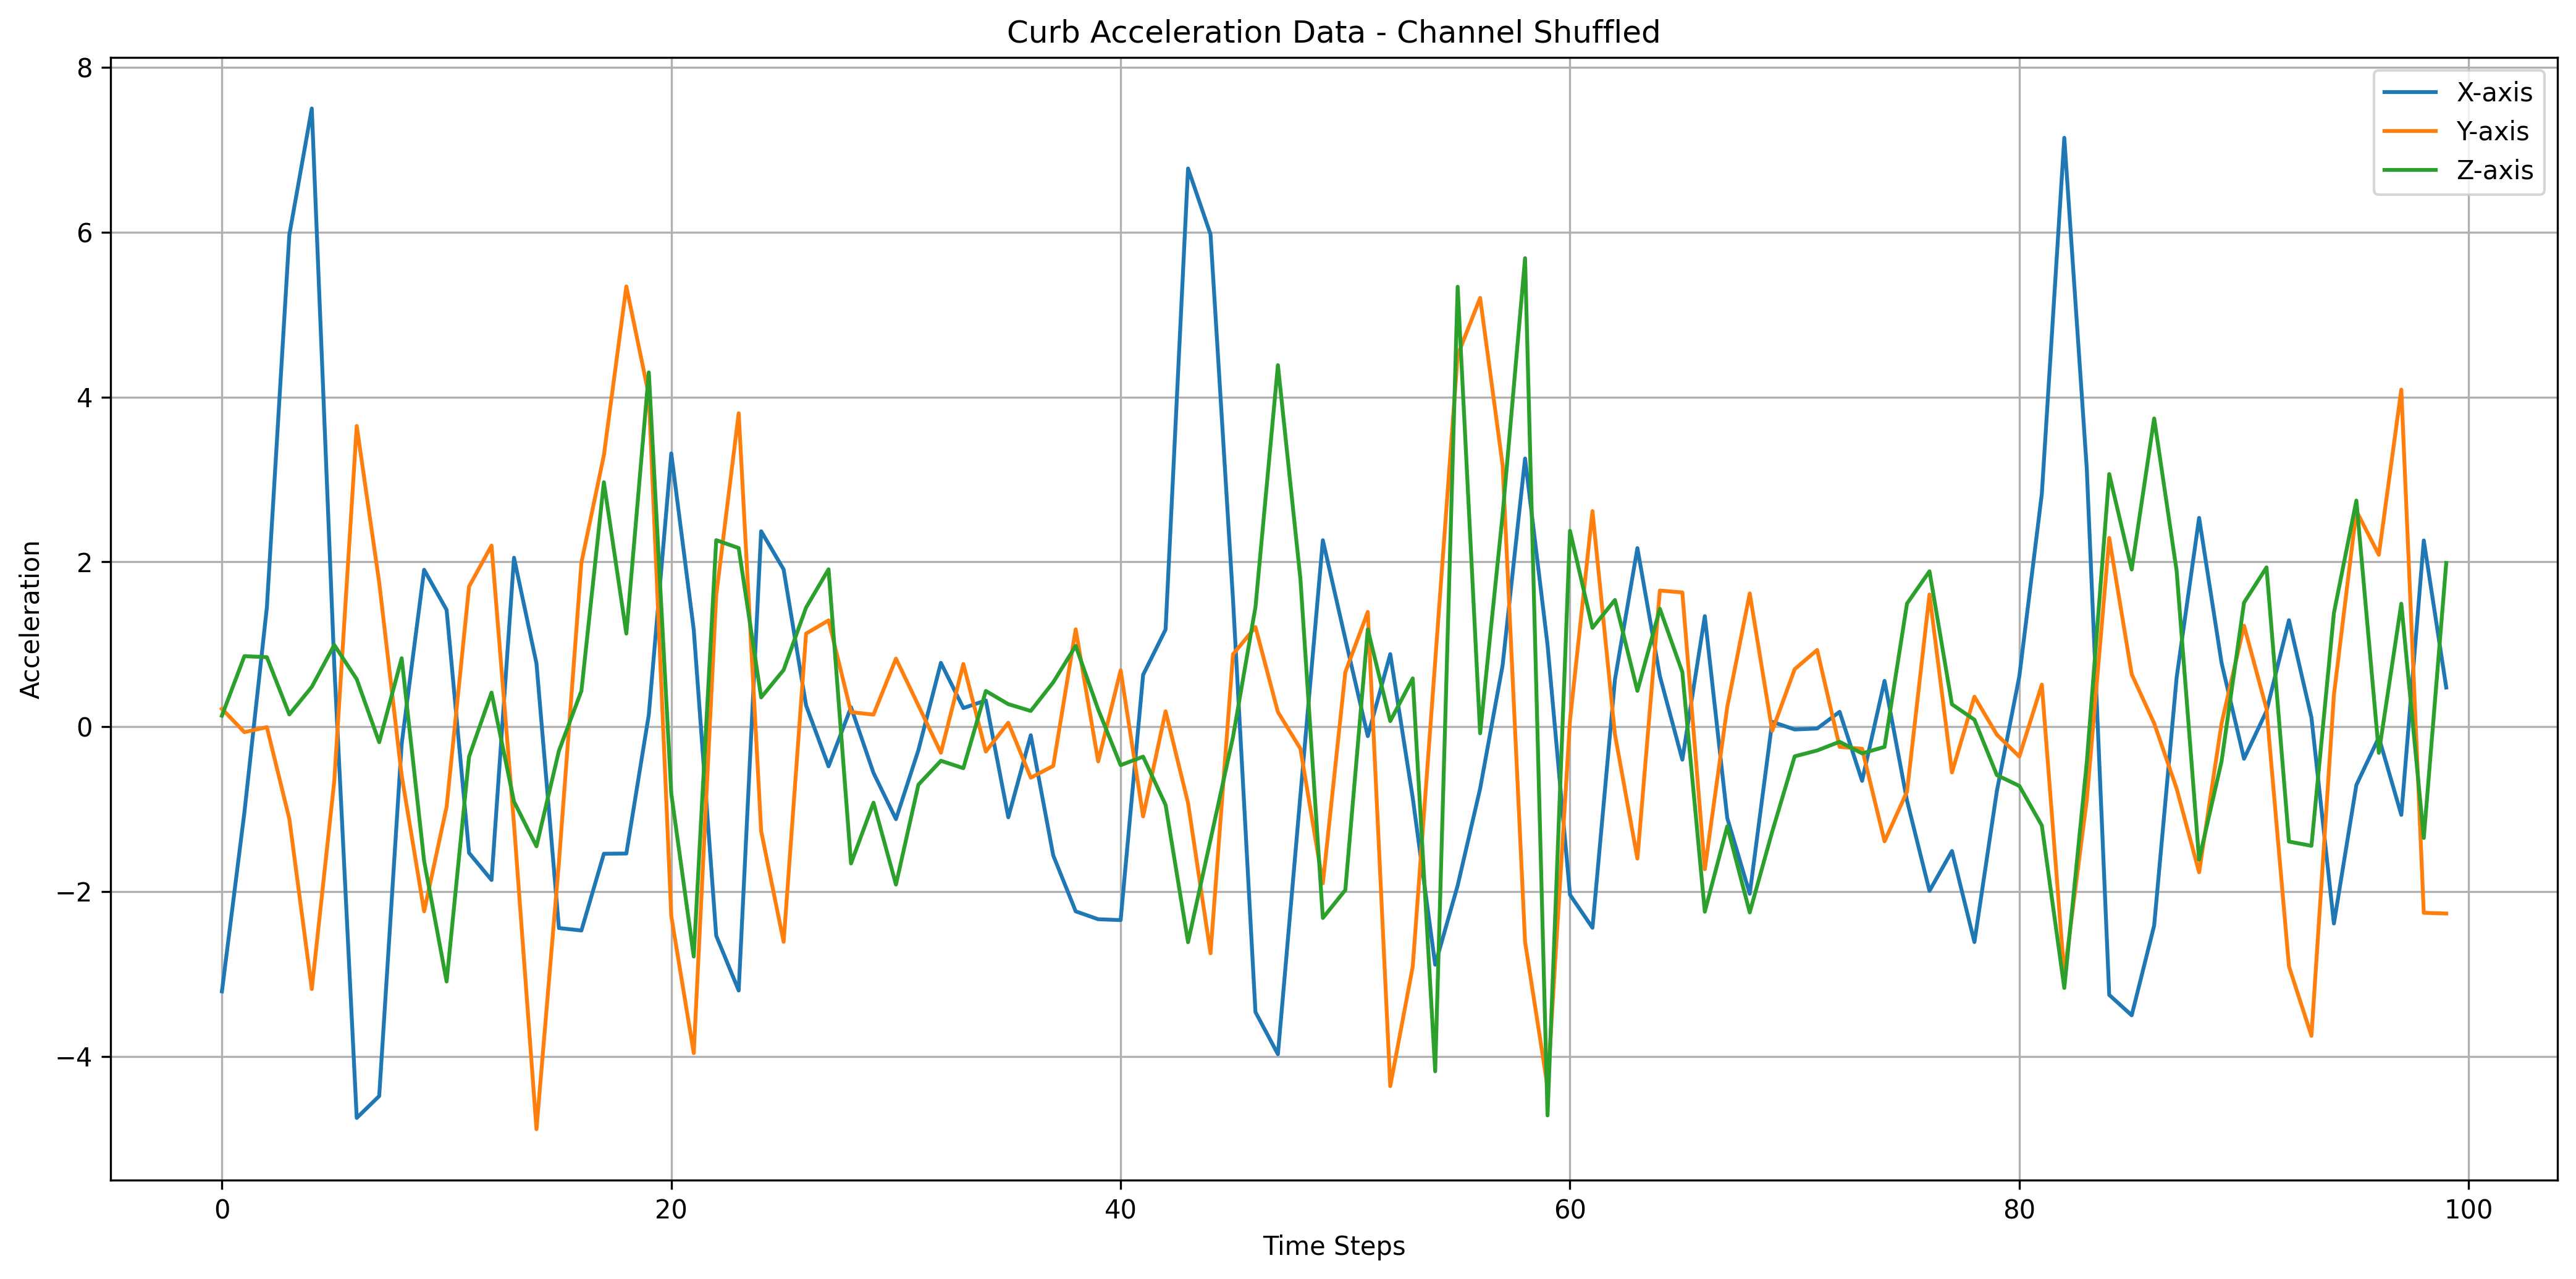

In [33]:
# Apply and plot channel shuffling
sample = np.expand_dims(curb_samples[30], axis=0)  # Add batch dimension (1, 100, 3)
shuffled_curb = channel_shuffle_transform_vectorized(sample)
shuffled_curb = np.squeeze(shuffled_curb)  # Remove batch dimension (100, 3)
plot_sample_data_numpy_bachelorarbeit(shuffled_curb, title="Curb Acceleration Data - Channel Shuffled")

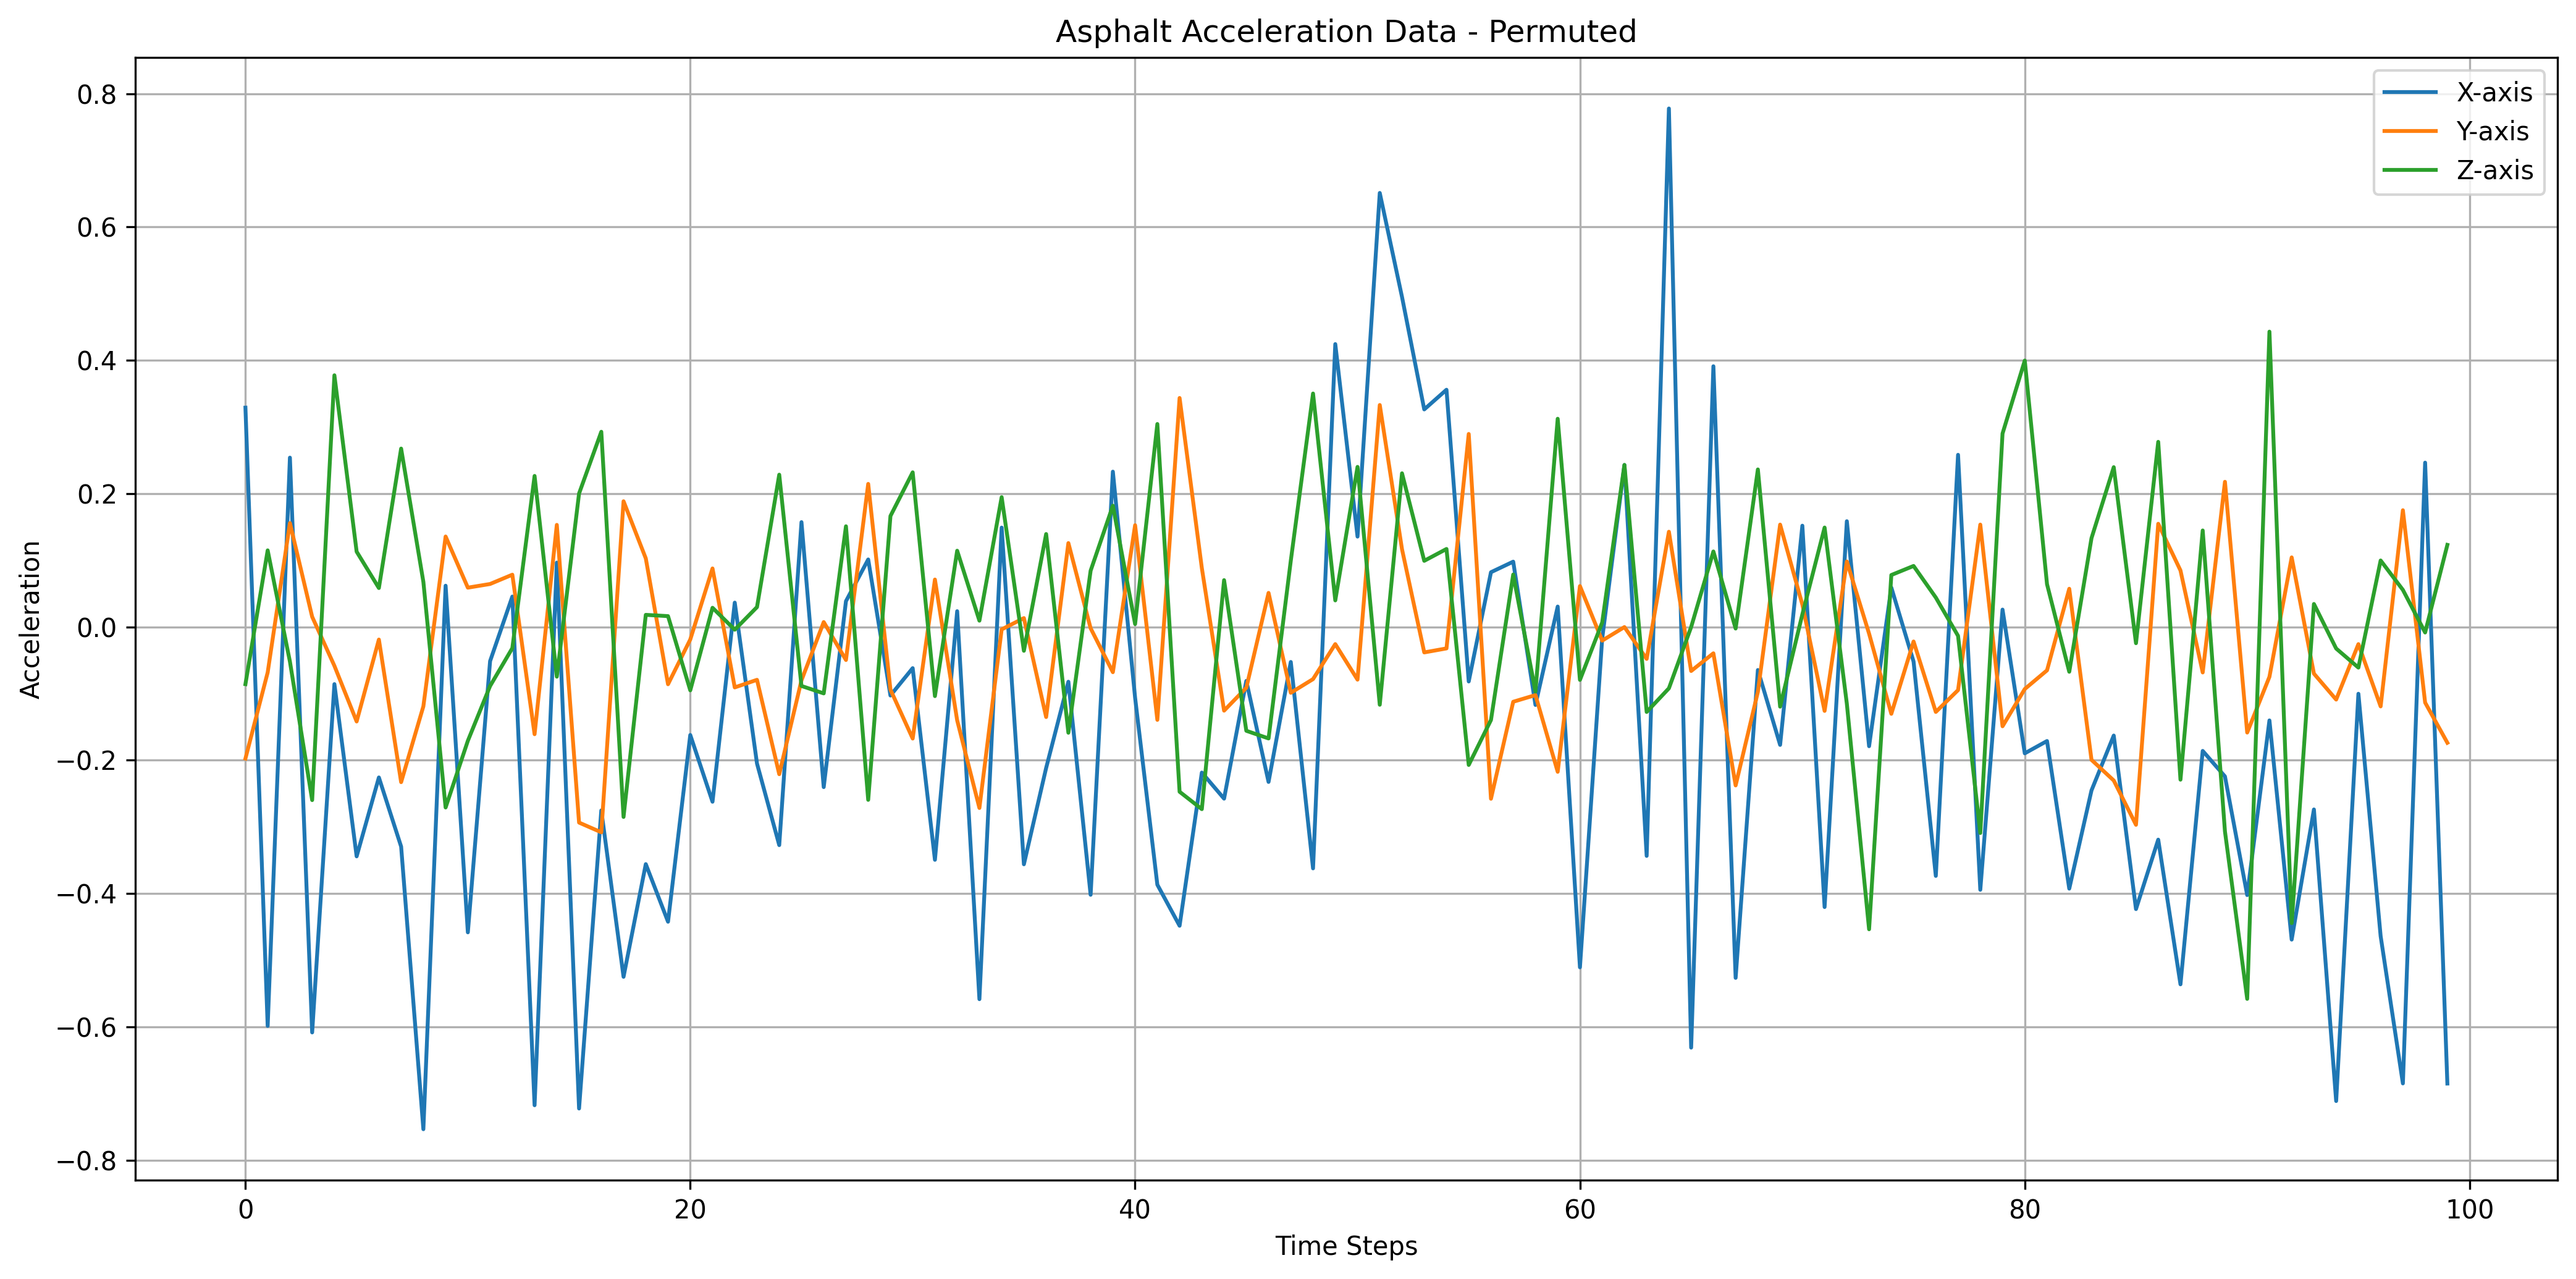

In [34]:
# Apply and plot time segment permutation for asphalt
sample = np.expand_dims(asphalt_samples[30], axis=0)  # Add batch dimension
permuted_asphalt = time_segment_permutation_transform_improved(sample)
permuted_asphalt = np.squeeze(permuted_asphalt)  # Remove batch dimension
plot_sample_data_numpy_bachelorarbeit(permuted_asphalt, title="Asphalt Acceleration Data - Permuted")



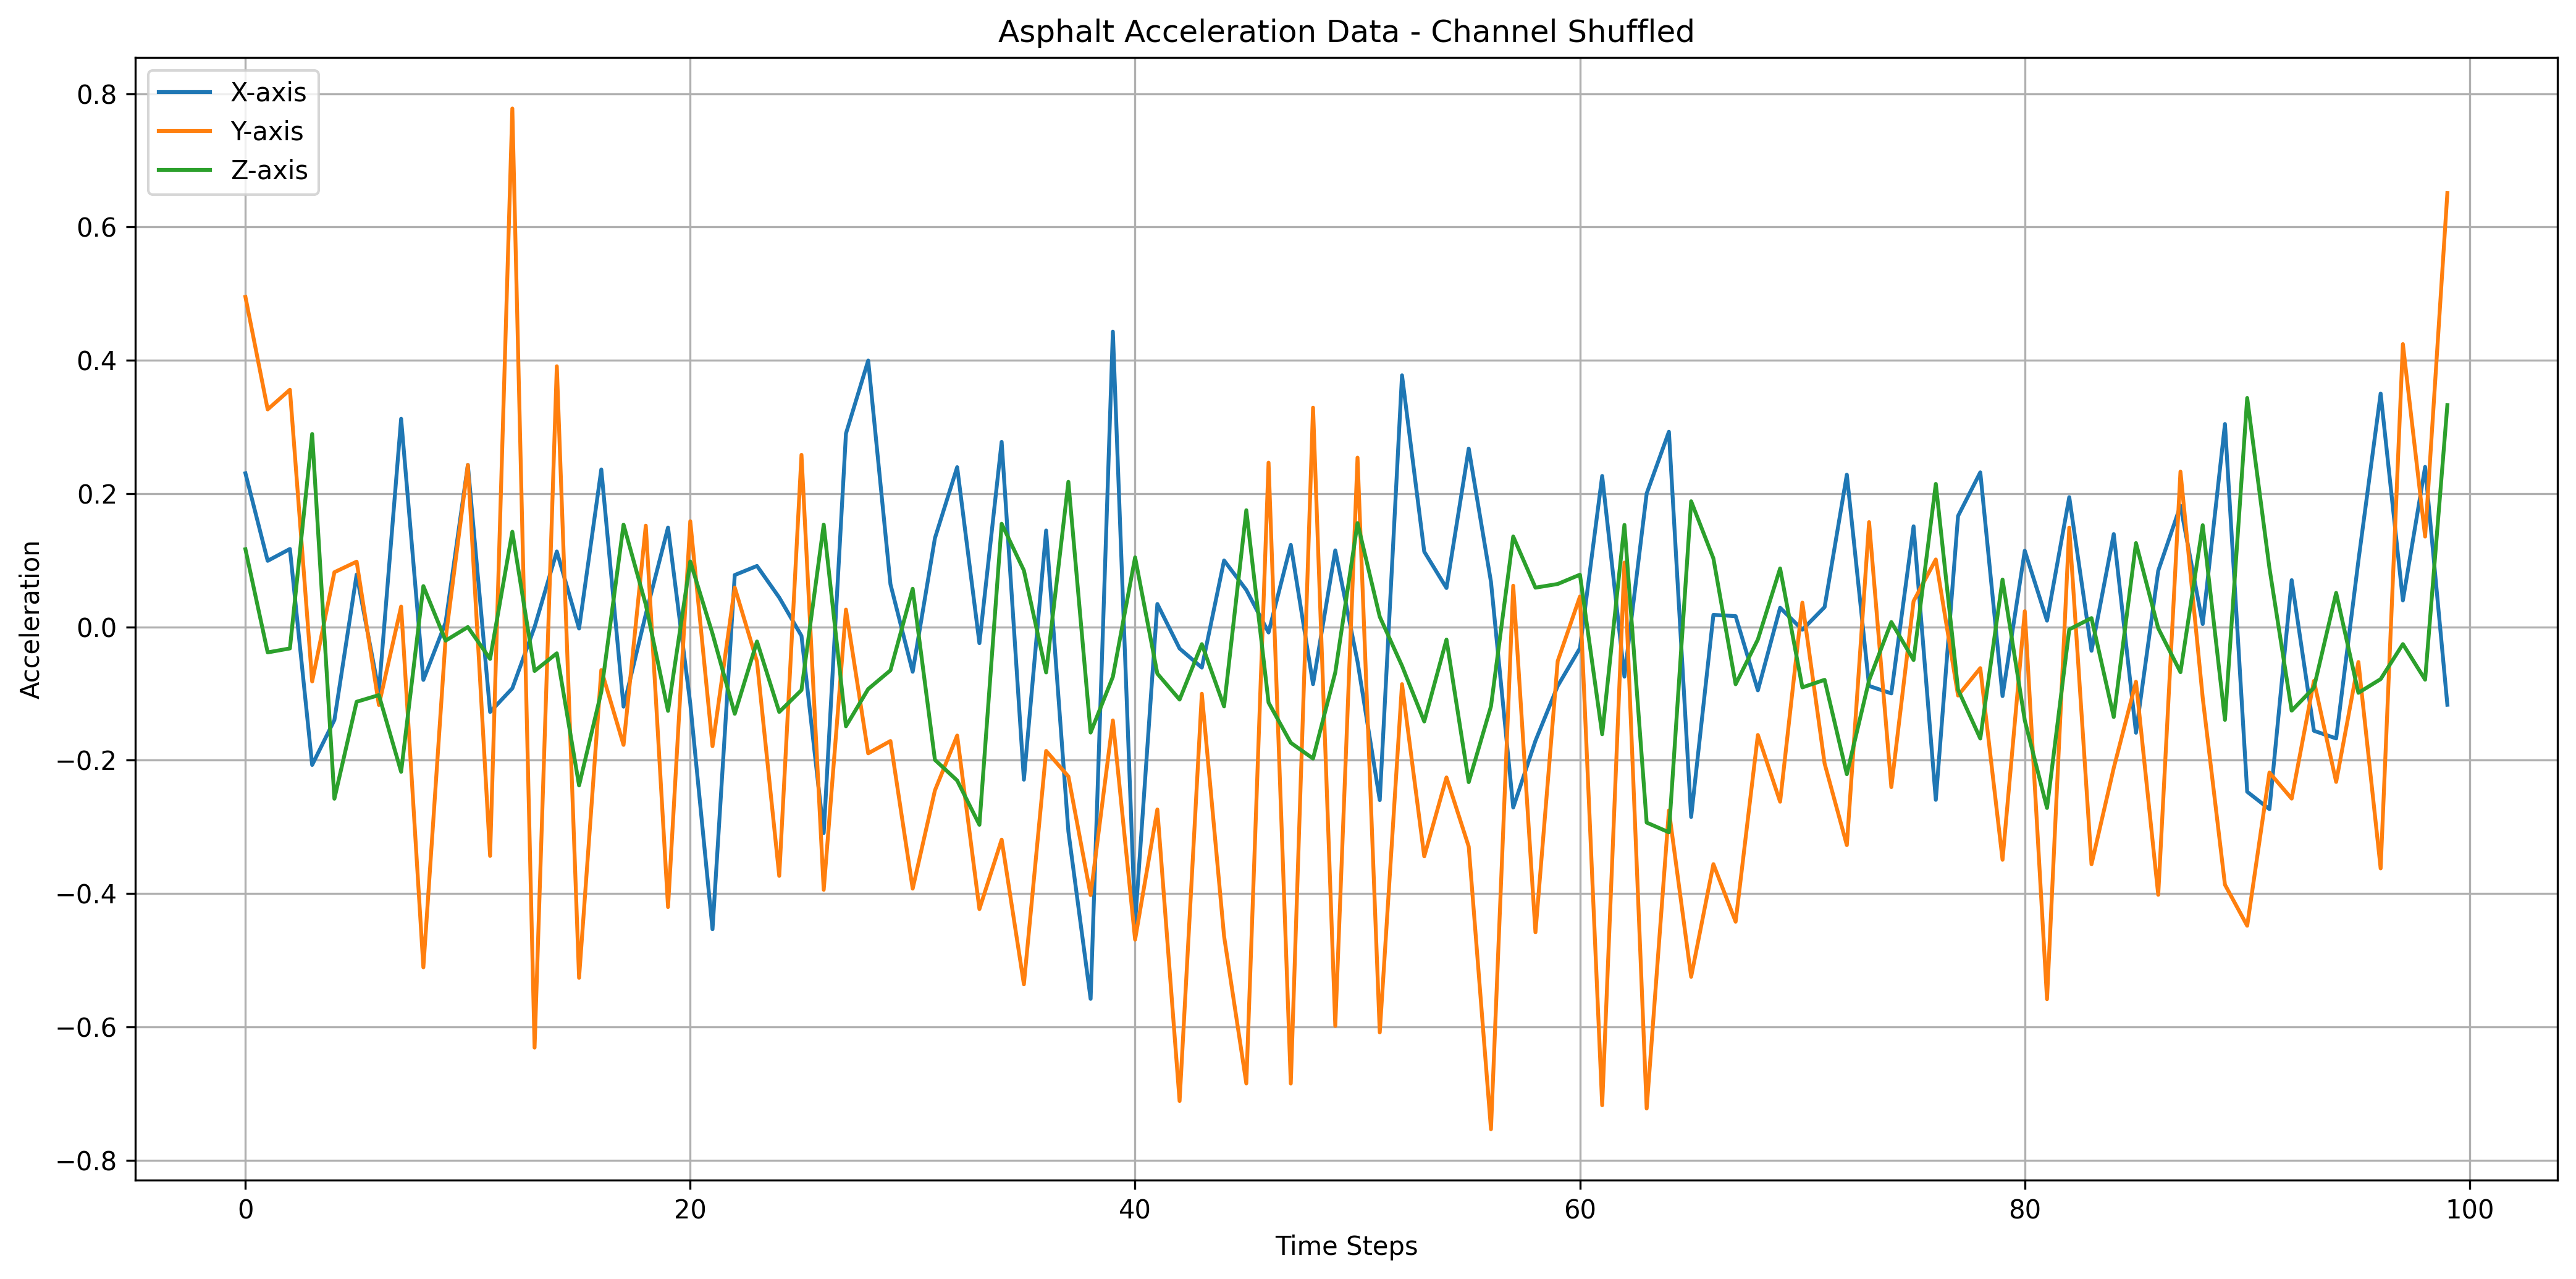

In [35]:
# Apply and plot channel shuffling for asphalt
sample = np.expand_dims(asphalt_samples[30], axis=0)  # Add batch dimension (1, 100, 3)
shuffled_asphalt = channel_shuffle_transform_vectorized(sample)
shuffled_asphalt = np.squeeze(shuffled_asphalt)  # Remove batch dimension (100, 3)
plot_sample_data_numpy_bachelorarbeit(shuffled_asphalt, title="Asphalt Acceleration Data - Channel Shuffled")